In [1]:
from mlpui.calculator import CalculatorBuilder
from ase import Atoms
calc = CalculatorBuilder.from_checkpoint(ckpt_path="../models/mlp/uma-m-1p1.pt",task="omol").build()

WARNING, you accessed latent_format from the model config object which doesn't exist. Please fix your code.



unet_config: {'model_name': 'uma', 'num_experts': 32, 'sphere_channels': 128, 'max_neighbors': 300, 'edge_channels': 128, 'norm_type': 'rms_norm_sh', 'cs_emb_grad': True, 'max_num_elements': 100, 'cutoff': 6, 'hidden_channels': 128, 'chg_spin_emb_type': 'rand_emb', 'mmax': 2, 'num_distance_basis': 128, 'num_layers': 10, 'ff_type': 'spectral', 'use_composition_embedding': True, 'lmax': 4, 'act_type': 'gate', 'has_mole': True, 'dataset_mapping': {'oc20': 'oc20', 'omol': 'omol', 'omat': 'omat', 'odac': 'odac', 'omc': 'omc'}, 'use_dataset_embedding': True, 'num_heads': -1, 'num_head_channels': 64, 'dtype': torch.float32}


Family: uma


In [2]:
import numpy as np
pos =np.load("./testdata/full_coord.npy")
ref_energy = np.load("./testdata/full_gs_energy.npy")

In [3]:
from scripts.md.batch_infer import run_batch
result = run_batch(pos,"./testdata/full_qm_type.npy",calc,charge=-1)
#result2 = run_batch(pos,"./testdata/full_qm_type.npy",calc,charge=1)

Inferring:   0%|          | 0/2800 [00:00<?, ?it/s]C:\Users\suwak\Documents\calculations\claude\MLPUI\mlpui\models\uma\uma.py:1139: UserWarning: index_reduce() is in beta and the API may change at any time. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorAdvancedIndexing.cpp:1513.)
  ).index_reduce_(
Inferring:  50%|█████     | 1404/2800 [12:57<12:52,  1.81it/s]


KeyboardInterrupt: 

In [4]:
pred_energy = []

for i in result:
    pred_energy.append(i["energy"])

In [5]:
from mlpui.unit import ENERGY

In [6]:
ref_energy = ENERGY(ref_energy,"kcal").convert_to("ev")

In [7]:
ref = ref_energy[0]

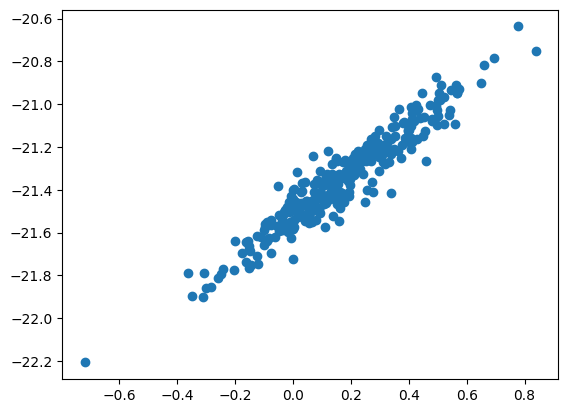

In [8]:
import matplotlib.pyplot as plt
plt.scatter(ref_energy-ref,pred_energy-ref)

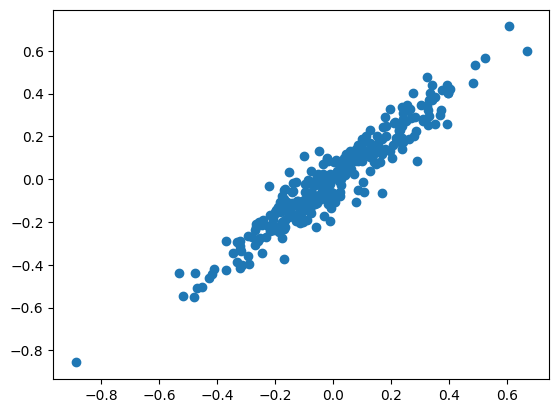

In [9]:
ref_mean = np.mean(ref_energy)
pred_mean = np.mean(pred_energy)
plt.scatter(ref_energy - ref_mean,pred_energy-pred_mean)
ref_energy -= ref_mean
pred_energy -= pred_mean

In [10]:
mae = np.sum(np.abs(ref_energy-pred_energy))/len(ref_energy)

In [11]:
ENERGY(mae,"ev").convert_to("kcal")

np.float64(1.2331459296388065)